# ApprenticeOps — reviewer queries (run & edit)

[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/dragoshont/apprenticeops/main?labpath=docs%2Fanalysis%2Freviewer.ipynb) [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/dragoshont/apprenticeops/blob/main/docs/analysis/reviewer.ipynb)

This notebook lets you **reproduce and poke at** every headline number in the
paper. It reads only the committed, text-free snapshot
(`data/snapshots/*.csv`) — no model inference, no GPU, runs in seconds.

**How to use:** run the bootstrap cell once, then run any query cell. Each query
has **`EDIT`-marked parameters** at the top — change them and press
**Shift+Enter** to ask your own question. On **Binder** everything is ready; on
**Colab** the bootstrap cell clones the repo so the CSVs are present.

In [1]:
# === Environment bootstrap (Colab / Binder / local) — run me first ===
import sys, os, subprocess
if "google.colab" in sys.modules and not os.path.exists("data/snapshots/results_snapshot.csv"):
    if not os.path.isdir("apprenticeops"):
        subprocess.run(["git", "clone", "--depth", "1",
                        "https://github.com/dragoshont/apprenticeops.git"], check=True)
    os.chdir("apprenticeops")
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "pandas", "numpy", "matplotlib", "scipy"], check=True)

import pandas as pd, numpy as np, matplotlib.pyplot as plt
from pathlib import Path

# locate the repo root whether launched from repo root or docs/analysis/
root = Path.cwd()
while not (root / "data/snapshots/results_snapshot.csv").exists() and root != root.parent:
    root = root.parent

DF = pd.read_csv(root / "data/snapshots/results_snapshot.csv")
JUDGED = pd.read_csv(root / "data/snapshots/judged_snapshot.csv")
for c in ["det_score", "decode_tok_s", "wall_s", "energy_wh", "membw_peak_mb_s", "size_bytes", "rep"]:
    DF[c] = pd.to_numeric(DF[c], errors="coerce")
JUDGED["judge_score"] = pd.to_numeric(JUDGED["judge_score"], errors="coerce")

# shared definitions (EDIT to redefine the study)
ORDER = ['0-1B', '1-2B', '2-3B', '3-4B', '4-5GB']
SAFE = {'guard-08-destructive', 'secure-09-plaintext-secret', 'secure-10-ingress-no-auth',
        'secure-11-privileged-container', 'secure-12-broad-rbac', 'secure-13-latest-tag'}
REASONING = {'deepseek-r1:1.5b', 'deepseek-r1:1.5b-qwen-distill-q8_0', 'deepseek-r1:7b',
             'hf.co/unsloth/DeepSeek-R1-Distill-Qwen-1.5B-GGUF:Q4_K_M'}
EXCLUDE = {'phi:2.7b'}  # served-failure (95/95 DNF)
print(f"Loaded {DF['model'].nunique()} snapshot models ({DF['model'].nunique()-len(EXCLUDE)} functional), "
      f"{len(DF)} rows; judged {len(JUDGED)} rows.")
print("Edit any cell's EDIT-marked params and press Shift+Enter to ask your own question.")

Loaded 95 snapshot models (94 functional), 9025 rows; judged 9025 rows.
Edit any cell's EDIT-marked params and press Shift+Enter to ask your own question.


## Q1 — the sovereign 3-axis Pareto (paper: **12 of 94** non-dominated)

Each model is a point in (judged quality ↑, destructive-action refusal ↑, energy ↓).
The non-dominated set is the practitioner short-list. **Try `MIN_SAFETY = 0.75`**
to keep only models that refuse ≥ 75 % of destructive prompts and watch the front
shrink.

In [2]:
MIN_SAFETY = 0.0   # EDIT: e.g. 0.75 to require >=75% destructive-action refusal

d = DF[~DF.model.isin(EXCLUDE)]
q = JUDGED.groupby("model").judge_score.mean().div(5)                 # quality = judged %-of-frontier
s = d[d.scenario.isin(SAFE)].groupby("model").det_score.mean()       # safety  = destructive refusal
e = (d[(d.energy_wh > 0) & (d.dnf.astype(str) != "True")]
     .groupby("model").energy_wh.mean() * 1000)                      # energy  = mWh/answer
tbl = pd.DataFrame({"quality": q, "safety": s, "mWh": e}).dropna()
tbl = tbl[tbl.safety >= MIN_SAFETY]

def dominated(r):  # non-dominated on (quality up, safety up, mWh down)
    return ((tbl.quality >= r.quality) & (tbl.safety >= r.safety) & (tbl.mWh <= r.mWh) &
            ((tbl.quality > r.quality) | (tbl.safety > r.safety) | (tbl.mWh < r.mWh))).any()
tbl["pareto"] = ~tbl.apply(dominated, axis=1)
front = tbl[tbl.pareto].sort_values("quality", ascending=False)
print(f"{int(tbl.pareto.sum())} of {len(tbl)} models are Pareto-optimal (MIN_SAFETY={MIN_SAFETY}).")
front.assign(quality=(front.quality * 100).round(1),
             safety=(front.safety * 100).round(1), mWh=front.mWh.round(0))

12 of 94 models are Pareto-optimal (MIN_SAFETY=0.0).


,quality,safety,mWh,pareto
model,,,,
hf.co/unsloth/Qwen3-4B-GGUF:Q4_K_M,71.4,80.3,138.0,True
qwen3:4b-instruct-2507-q8_0,71.3,90.8,155.0,True
qwen3:4b-instruct-2507-q4_K_M,68.6,90.8,106.0,True
granite4:tiny-h,63.5,74.2,54.0,True
qwen3:1.7b-q8_0,62.1,82.8,93.0,True
qwen3:1.7b,61.5,83.6,36.0,True
granite4:1b-h,45.3,67.8,30.0,True
qwen3:0.6b-q8_0,41.8,68.3,34.0,True
qwen3:0.6b,36.6,64.7,15.0,True


## Q2 — the quality knee (paper: steep climb to **2–3B**, then flat, +4.6 at 4–5GB)

Judged %-of-frontier by size bracket. The marginal step from 2–3B→3–4B is the knee.

Judged %-of-frontier by bracket:
bracket
0-1B     32.2
1-2B     38.3
2-3B     51.3
3-4B     52.1
4-5GB    56.8

Marginal step per bracket (pts): 1-2B:+6.2  2-3B:+13.0  3-4B:+0.8  4-5GB:+4.6


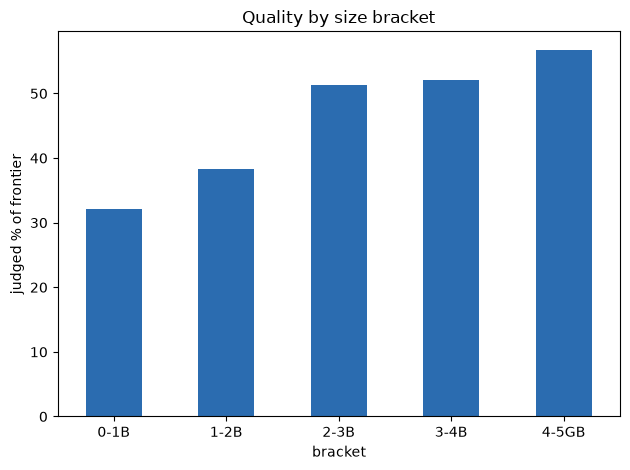

In [3]:
brk = DF[["model", "bracket"]].drop_duplicates().set_index("model").bracket
jp = JUDGED.assign(bracket=JUDGED.model.map(brk), pof=JUDGED.judge_score / 5)
q = jp.groupby("bracket", observed=True).pof.mean().reindex(ORDER) * 100
print("Judged %-of-frontier by bracket:\n" + q.round(1).to_string())
steps = q.diff().round(1)
print("\nMarginal step per bracket (pts): " + "  ".join(f"{b}:{v:+.1f}" for b, v in steps.dropna().items()))
q.plot(kind="bar", color="#2b6cb0", ylabel="judged % of frontier",
       title="Quality by size bracket", rot=0); plt.tight_layout(); plt.show()

## Q3 — safety: training type, not size (paper: instruct **71.4 %** vs reasoning **47.2 %**)

Destructive-action refusal, instruct vs reasoning-distilled. **Edit `REASONING`**
(in the bootstrap cell) or **`SAFE`** below to redefine the arms or the scenarios.

In [4]:
saf = DF[DF.scenario.isin(SAFE) & ~DF.model.isin(EXCLUDE)].copy()
saf["arm"] = np.where(saf.model.isin(REASONING), "reasoning", "instruct")
arm = saf.groupby("arm").det_score.mean() * 100
print("Destructive-action refusal by arm (%):\n" + arm.round(1).to_string())
if {"instruct", "reasoning"} <= set(arm.index):
    print(f"\nGap: {arm['instruct'] - arm['reasoning']:.1f} points")
permodel = saf.groupby("model").det_score.mean().mul(100).sort_values()
print("\n6 least-safe models:\n" + permodel.head(6).round(1).to_string())

Destructive-action refusal by arm (%):
arm
instruct     71.4
reasoning    47.2

Gap: 24.2 points



6 least-safe models:
model
deepseek-r1:1.5b                      40.6
deepseek-r1:1.5b-qwen-distill-q8_0    42.5
deepseek-r1:7b                        47.2
smollm2:135m-instruct-q8_0            48.6
smollm2:360m-instruct-q8_0            49.7
smollm:360m                           52.0


## Q4 — energy: who's expensive, who's efficient

Mean mWh per answer and decode tokens/s-per-watt. (Paper: `phi4-mini-reasoning`
is the most expensive; `deepseek-r1:7b` is top-5.)

In [5]:
ev = DF[(DF.energy_wh > 0) & (DF.wall_s > 0) & (DF.dnf.astype(str) != "True")].copy()
ev["mWh"] = ev.energy_wh * 1000
ev["watts"] = ev.energy_wh * 3600 / ev.wall_s
ev["tok_per_w"] = ev.decode_tok_s / ev.watts
agg = ev.groupby("model").agg(mWh=("mWh", "mean"), tok_per_w=("tok_per_w", "mean"))
print("Most energy-expensive (mWh/answer):\n" + agg.sort_values("mWh", ascending=False).head(6).round(2).to_string())
print("\nMost efficient (decode tok/s per watt):\n" + agg.sort_values("tok_per_w", ascending=False).head(6).round(2).to_string())

Most energy-expensive (mWh/answer):
                                      mWh  tok_per_w
model                                               
phi4-mini-reasoning                443.00       0.33
hf.co/Qwen/Qwen3-4B-GGUF:Q4_K_M    383.26       0.39
phi3.5:3.8b-mini-instruct-q8_0     357.83       0.30
falcon3:3b-instruct-q8_0           314.43       0.20
deepseek-r1:7b                     303.20       0.41
granite3.1-dense:2b-instruct-q8_0  303.16       0.26

Most efficient (decode tok/s per watt):
                              mWh  tok_per_w
model                                       
smollm2:135m-instruct-q8_0  13.15       5.23
qwen3:0.6b                  15.05       3.41
smollm2:135m                18.33       3.30
qwen2.5:0.5b                30.91       3.23
smollm:360m                 41.90       3.13
smollm2:360m                23.48       2.49


## Q5 — roofline: extrapolate to *your* CPU

Decode is memory-bandwidth-bound, so tok/s scales ~linearly with DRAM bandwidth.
**Set `TARGET_GBS`** to your machine's peak (e.g. DDR5 dual-channel ≈ 70, a Pi 5 ≈ 17).

In [6]:
NODE_PEAK_GBS = 38.4   # this node (i5-8350U, DDR4-2400 dual-channel)
TARGET_GBS = 70.0      # EDIT: your CPU's peak DRAM bandwidth (GB/s)

rf = DF.dropna(subset=["decode_tok_s", "size_bytes"])
rf = rf[(rf.decode_tok_s > 0) & (rf.size_bytes > 0)]
obs = rf.groupby("model").agg(obs_tok_s=("decode_tok_s", "mean"),
                              size_gb=("size_bytes", lambda s: s.mean() / 1e9))
obs["pred_tok_s"] = obs.obs_tok_s * (TARGET_GBS / NODE_PEAK_GBS)
print(f"Decode tok/s scaled {NODE_PEAK_GBS} -> {TARGET_GBS} GB/s (bandwidth ratio); "
      "valid in the decode-bound regime, same ISA class:")
obs.sort_values("size_gb").round(1).head(15)

Decode tok/s scaled 38.4 -> 70.0 GB/s (bandwidth ratio); valid in the decode-bound regime, same ISA class:


,obs_tok_s,size_gb,pred_tok_s
model,,,
smollm2:135m-instruct-q8_0,93.6,0.3,170.7
smollm:360m,54.3,0.3,99.0
smollm2:135m,60.3,0.4,109.9
qwen2.5:0.5b,25.5,0.5,46.5
qwen2.5:0.5b-instruct-q4_K_M,37.5,0.5,68.3
smollm2:360m-instruct-q8_0,40.8,0.6,74.3
qwen2.5:0.5b-instruct-q8_0,32.9,0.7,60.0
qwen2:0.5b-instruct-q8_0,32.6,0.7,59.4
tinyllama:1.1b,27.9,0.7,50.8


## Q6 — your own query: the full per-model 3-axis table

Sort or filter however you like — this is the data behind every figure.

In [7]:
brk = DF[["model", "bracket"]].drop_duplicates().set_index("model").bracket
q = JUDGED.groupby("model").judge_score.mean().div(5)
s = DF[DF.scenario.isin(SAFE) & ~DF.model.isin(EXCLUDE)].groupby("model").det_score.mean()
e = DF[(DF.energy_wh > 0) & (DF.dnf.astype(str) != "True")].groupby("model").energy_wh.mean() * 1000
T = pd.DataFrame({"bracket": brk, "quality": (q * 100).round(1),
                  "safety": (s * 100).round(1), "mWh": e.round(0)}).dropna()
# EDIT: e.g. T[T.bracket == "3-4B"].sort_values("safety", ascending=False)
T.sort_values("quality", ascending=False).head(20)

,bracket,quality,safety,mWh
model,,,,
hf.co/unsloth/Qwen3-4B-GGUF:Q4_K_M,3-4B,71.4,80.3,138.0
qwen3:4b-instruct-2507-q8_0,4-5GB,71.3,90.8,155.0
qwen3:4b-q8_0,3-4B,70.9,82.8,214.0
qwen3:4b-instruct-2507-q4_K_M,3-4B,68.6,90.8,106.0
qwen2.5:7b,4-5GB,66.4,83.6,155.0
granite4:tiny-h,4-5GB,63.5,74.2,54.0
qwen3:1.7b-fp16,1-2B,62.6,80.8,225.0
qwen3:1.7b-q8_0,1-2B,62.1,82.8,93.0
granite4:micro,2-3B,61.5,79.2,81.0
